In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from collections import Counter

In [2]:
import pandas as pd
import os # Import the 'os' module for clarity, though it's optional here

# Define the file name
file_name = 'Diabetes Missing Data.csv'

# Check if the file exists (optional, but good practice)
if os.path.exists(file_name):
    # Load the data into a pandas DataFrame
    df = pd.read_csv(file_name)
    print(" Data loaded successfully!")
    # print(df.head()) # Uncomment to see the first few rows
else:
    print(f" Error: File '{file_name}' not found in the current directory.")

 Data loaded successfully!


--- Data Dimensions ---
Rows: 768, Columns: 9

--- Data Types and Missing Values (Initial Check) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Pregnant           768 non-null    int64  
 1   Glucose            763 non-null    float64
 2   Diastolic_BP       733 non-null    float64
 3   Skin_Fold          541 non-null    float64
 4   Serum_Insulin      394 non-null    float64
 5   BMI                757 non-null    float64
 6   Diabetes_Pedigree  768 non-null    float64
 7   Age                768 non-null    int64  
 8   Class              768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB

--- Descriptive Statistics ---
                   count        mean         std     min       25%       50%  \
Pregnant           768.0    3.845052    3.369578   0.000   1.00000    3.0000   
Glucose            763.0

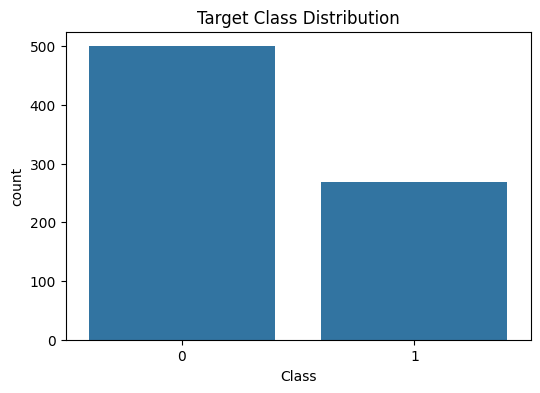


--- Count of Zero Values in Critical Features ---
'Glucose': 0 zeros (0.0%)
'Diastolic_BP': 0 zeros (0.0%)
'Skin_Fold': 0 zeros (0.0%)
'Serum_Insulin': 0 zeros (0.0%)
'BMI': 0 zeros (0.0%)


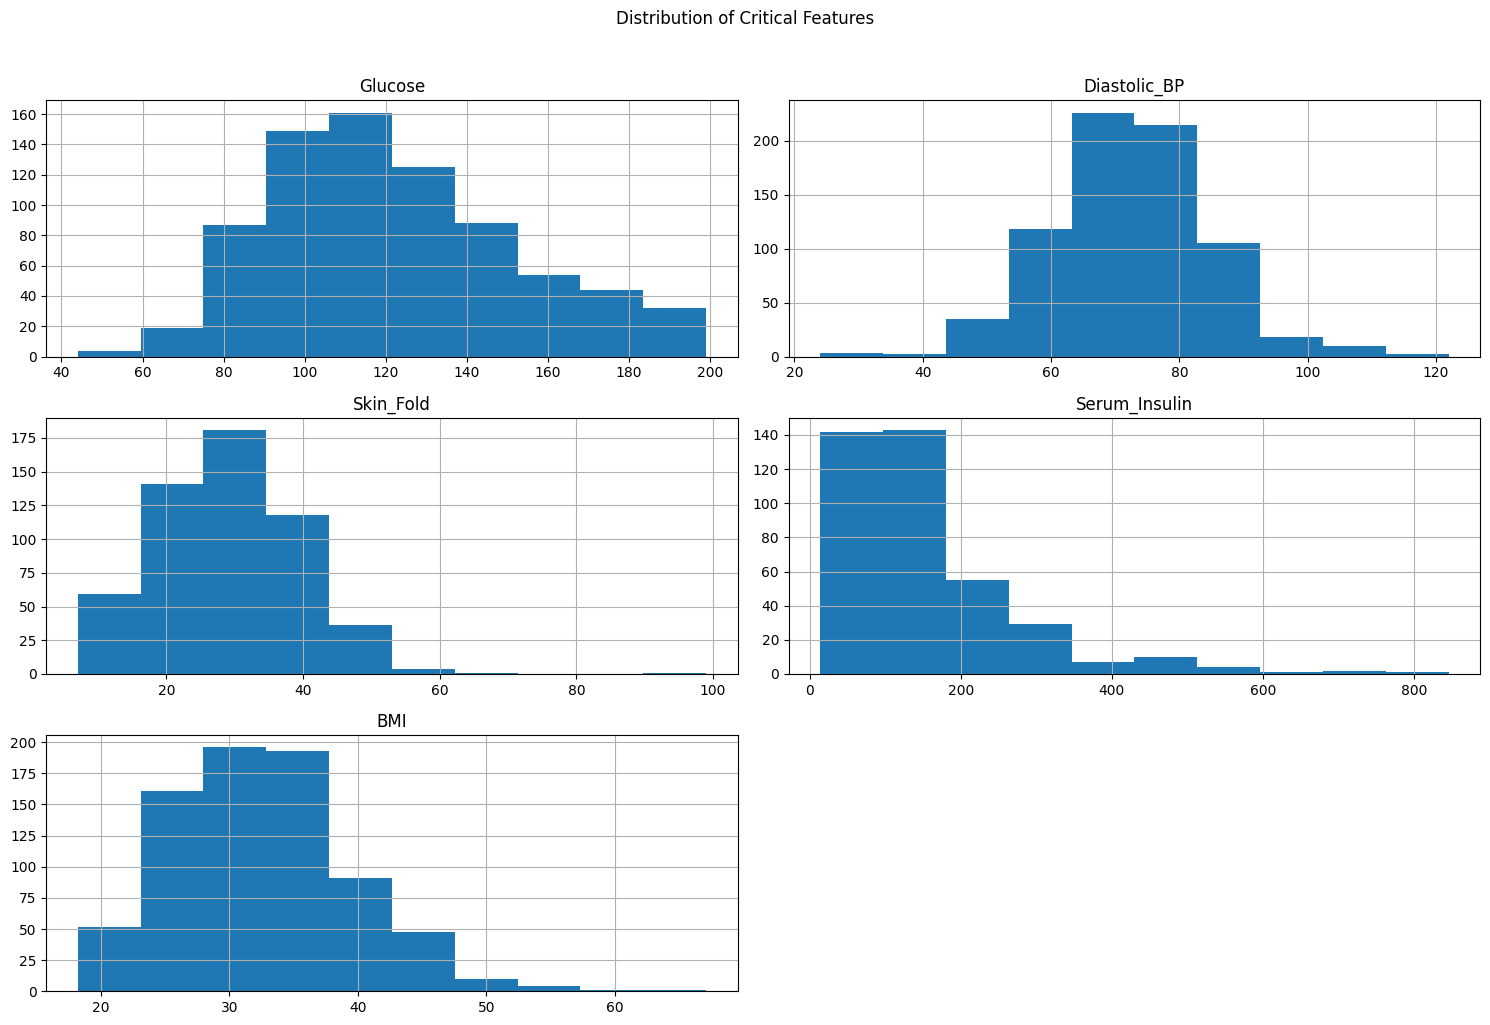

In [3]:
## Initial Data Assessment

print("--- Data Dimensions ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- Data Types and Missing Values (Initial Check) ---")
df.info()

print("\n--- Descriptive Statistics ---")
print(df.describe().T)

print("\n--- Class Distribution (Target Variable) ---")
class_counts = df['Class'].value_counts(normalize=True) * 100
print(class_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Target Class Distribution')
plt.show()

print("\n--- Count of Zero Values in Critical Features ---")
zero_counts = {}
critical_features = ['Glucose', 'Diastolic_BP', 'Skin_Fold', 'Serum_Insulin', 'BMI']

for col in critical_features:
    count = (df[col] == 0).sum()
    zero_counts[col] = count
    print(f"'{col}': {count} zeros ({round(count/df.shape[0]*100, 2)}%)")

df[critical_features].hist(figsize=(15, 10))
plt.suptitle('Distribution of Critical Features', y=1.02)
plt.tight_layout()
plt.show()

 Zeros replaced with NaN.


<Figure size 1000x600 with 0 Axes>

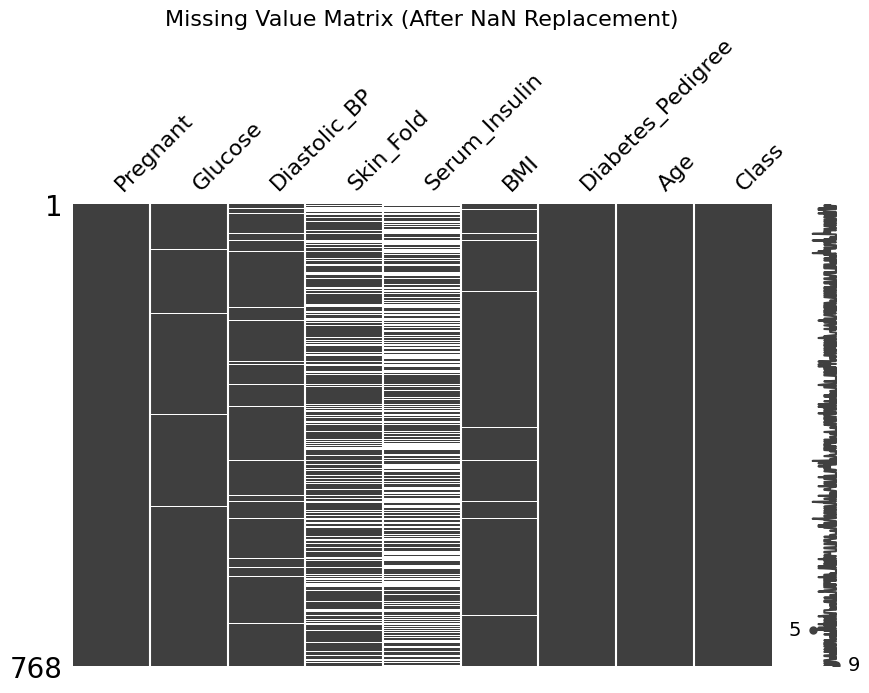


--- Documenting Missing Value Percentages ---
Serum_Insulin    48.70
Skin_Fold        29.56
Diastolic_BP      4.56
BMI               1.43
Glucose           0.65
dtype: float64

 Median Imputation applied to all critical features.

--- Check: Number of missing values after Imputation ---
Pregnant             0
Glucose              0
Diastolic_BP         0
Skin_Fold            0
Serum_Insulin        0
BMI                  0
Diabetes_Pedigree    0
Age                  0
Class                0
dtype: int64


In [4]:
from sklearn.impute import SimpleImputer
critical_features = ['Glucose', 'Diastolic_BP', 'Skin_Fold', 'Serum_Insulin', 'BMI']

df_cleaned = df.copy()
df_cleaned[critical_features] = df_cleaned[critical_features].replace(0, np.nan)

print(" Zeros replaced with NaN.")

plt.figure(figsize=(10, 6))
msno.matrix(df_cleaned, figsize=(10, 6))
plt.title('Missing Value Matrix (After NaN Replacement)', fontsize=16)
plt.show()

print("\n--- Documenting Missing Value Percentages ---")
missing_percentage = df_cleaned.isnull().sum() / len(df_cleaned) * 100
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False).round(2))


imputer = SimpleImputer(missing_values=np.nan, strategy='median')

df_cleaned[critical_features] = imputer.fit_transform(df_cleaned[critical_features])

print("\n Median Imputation applied to all critical features.")
print("\n--- Check: Number of missing values after Imputation ---")
print(df_cleaned.isnull().sum())


 Outliers detected and treated (capped) using the IQR method.


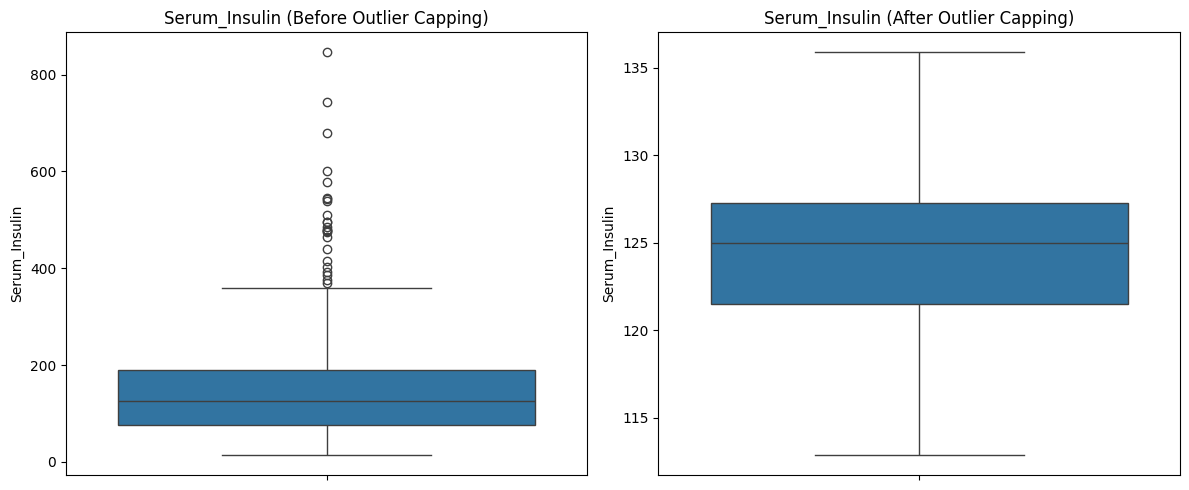


--- Head of the Final Cleaned Data (Phase 2) ---
   Pregnant  Glucose  Diastolic_BP  Skin_Fold  Serum_Insulin   BMI  \
0         6    148.0          72.0       35.0        125.000  33.6   
1         1     85.0          66.0       29.0        125.000  26.6   
2         8    183.0          64.0       29.0        125.000  23.3   
3         1     89.0          66.0       23.0        112.875  28.1   
4         0    137.0          40.0       35.0        135.875  43.1   

   Diabetes_Pedigree   Age  Class  
0              0.627  50.0      1  
1              0.351  31.0      0  
2              0.672  32.0      1  
3              0.167  21.0      0  
4              1.200  33.0      1  


In [5]:
# Identify numerical columns for outlier treatment
numerical_cols = ['Glucose', 'Diastolic_BP', 'Skin_Fold', 'Serum_Insulin', 'BMI', 'Diabetes_Pedigree', 'Age']

def cap_outliers_iqr(df, col):
    """Detects and caps outliers in a column using the IQR method."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

    return df
for col in numerical_cols:
    df_cleaned = cap_outliers_iqr(df_cleaned, col)

print("\n Outliers detected and treated (capped) using the IQR method.")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Serum_Insulin'])
plt.title('Serum_Insulin (Before Outlier Capping)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned['Serum_Insulin'])
plt.title('Serum_Insulin (After Outlier Capping)')

plt.tight_layout()
plt.show()

print("\n--- Head of the Final Cleaned Data (Phase 2) ---")
print(df_cleaned.head())


In [6]:
# Create a copy of the cleaned DataFrame for transformation
df_transformed = df_cleaned.copy()

age_bins = [20, 35, 55, df_transformed['Age'].max()]
age_labels = ['young', 'middle_aged', 'senior']
df_transformed['Age_Group'] = pd.cut(
    df_transformed['Age'],
    bins=age_bins,
    labels=age_labels,
    right=False,
    include_lowest=True
)
print(" Age_Group feature created.")

bmi_bins = [0, 18.5, 25, 30, df_transformed['BMI'].max() + 1]
bmi_labels = ['underweight', 'normal', 'overweight', 'obese']
df_transformed['BMI_Category'] = pd.cut(
    df_transformed['BMI'],
    bins=bmi_bins,
    labels=bmi_labels,
    right=False
)
print(" BMI_Category feature created.")

glucose_bins = [0, 99, 126, df_transformed['Glucose'].max() + 1]
glucose_labels = ['normal', 'pre_diabetic', 'diabetic']
df_transformed['Glucose_Category'] = pd.cut(
    df_transformed['Glucose'],
    bins=glucose_bins,
    labels=glucose_labels,
    right=False
)
print(" Glucose_Category feature created.")

print("\n--- New Categorical Features ---")
print(df_transformed[['Age_Group', 'BMI_Category', 'Glucose_Category']].head())

 Age_Group feature created.
 BMI_Category feature created.
 Glucose_Category feature created.

--- New Categorical Features ---
     Age_Group BMI_Category Glucose_Category
0  middle_aged        obese         diabetic
1        young   overweight           normal
2        young       normal         diabetic
3        young   overweight           normal
4        young        obese         diabetic


In [7]:
from sklearn.preprocessing import OneHotEncoder


categorical_features = ['Age_Group', 'BMI_Category', 'Glucose_Category']

df_transformed = pd.get_dummies(
    df_transformed,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("\n Encoding applied to new categorical features.")
print(f"New number of columns: {df_transformed.shape[1]}")
print(list(df_transformed.columns))


 Encoding applied to new categorical features.
New number of columns: 16
['Pregnant', 'Glucose', 'Diastolic_BP', 'Skin_Fold', 'Serum_Insulin', 'BMI', 'Diabetes_Pedigree', 'Age', 'Class', 'Age_Group_middle_aged', 'Age_Group_senior', 'BMI_Category_normal', 'BMI_Category_overweight', 'BMI_Category_obese', 'Glucose_Category_pre_diabetic', 'Glucose_Category_diabetic']


In [8]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Identify numerical features that need scaling
numerical_cols_to_scale = [
    'Pregnant', 'Glucose', 'Diastolic_BP', 'Skin_Fold',
    'Serum_Insulin', 'BMI', 'Diabetes_Pedigree', 'Age'
]

scaler = StandardScaler()

df_transformed[numerical_cols_to_scale] = scaler.fit_transform(
    df_transformed[numerical_cols_to_scale]
)

print("\n StandardScaler applied to all numerical features.")
print("\n--- Head of Final Transformed Data (Phase 3) ---")
print(df_transformed.head())


 StandardScaler applied to all numerical features.

--- Head of Final Transformed Data (Phase 3) ---
   Pregnant   Glucose  Diastolic_BP  Skin_Fold  Serum_Insulin       BMI  \
0  0.639947  0.866045     -0.030632   0.824667       0.039062  0.181092   
1 -0.844885 -1.205066     -0.543914   0.017945       0.039062 -0.869465   
2  1.233880  2.016662     -0.715008   0.017945       0.039062 -1.364728   
3 -0.844885 -1.073567     -0.543914  -0.788777      -1.494110 -0.644346   
4 -1.141852  0.504422     -2.768136   0.824667       1.414175  1.606849   

   Diabetes_Pedigree       Age  Class  Age_Group_middle_aged  \
0           0.588927  1.445691      1                      1   
1          -0.378101 -0.189304      0                      0   
2           0.746595 -0.103252      1                      0   
3          -1.022787 -1.049828      0                      0   
4           2.596563 -0.017199      1                      0   

   Age_Group_senior  BMI_Category_normal  BMI_Category_overwei

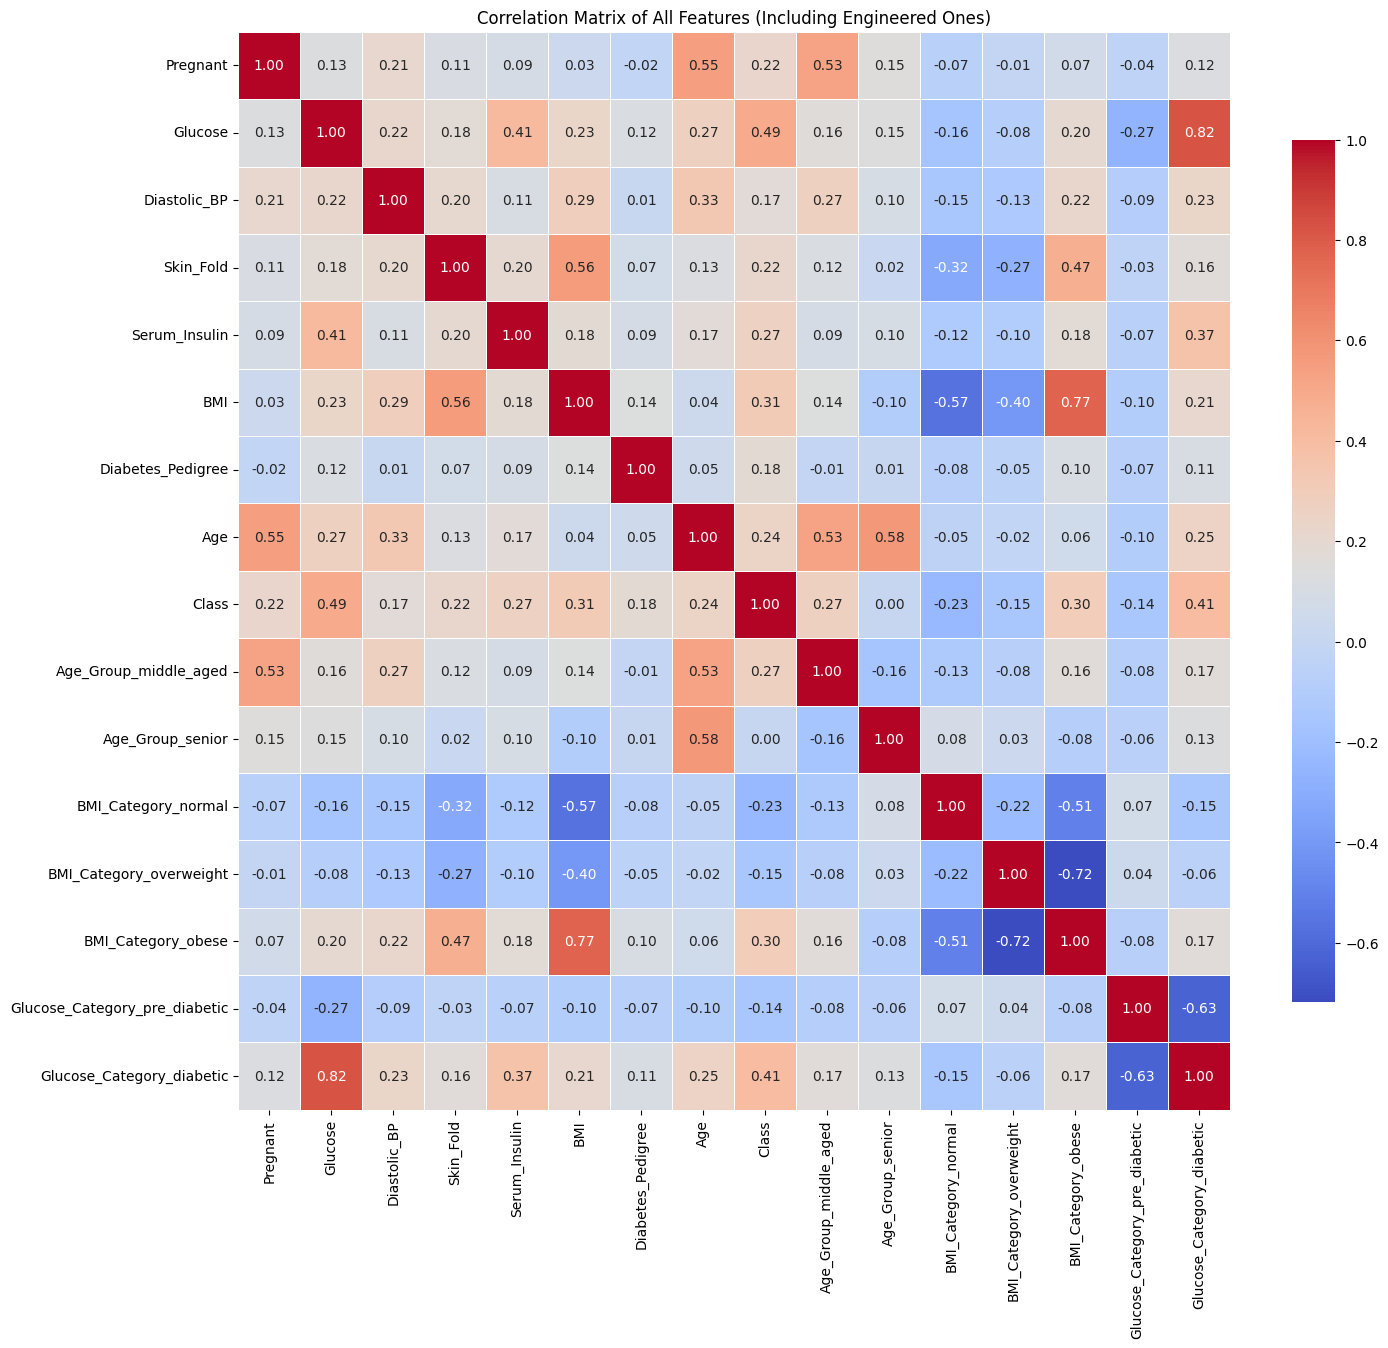


--- Top 10 Features based on Mutual Information ---
Glucose                          0.122578
Glucose_Category_diabetic        0.089623
BMI                              0.083377
Pregnant                         0.053493
BMI_Category_obese               0.051300
Age                              0.039881
Age_Group_middle_aged            0.033639
Serum_Insulin                    0.033057
BMI_Category_normal              0.027346
BMI_Category_overweight          0.027105
Skin_Fold                        0.013757
Glucose_Category_pre_diabetic    0.011594
Diastolic_BP                     0.003102
Diabetes_Pedigree                0.001911
Age_Group_senior                 0.000000
dtype: float64

 SelectKBest identified and selected the top features.
Features selected: ['Glucose', 'Glucose_Category_diabetic', 'BMI', 'Pregnant', 'BMI_Category_obese', 'Age', 'Age_Group_middle_aged', 'Serum_Insulin', 'BMI_Category_normal', 'BMI_Category_overweight']


In [9]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Use the df_transformed DataFrame from Phase 3
df_reduction = df_transformed.copy()

X = df_reduction.drop('Class', axis=1)
y = df_reduction['Class']
plt.figure(figsize=(16, 14))
correlation_matrix = df_reduction.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix of All Features (Including Engineered Ones)')
plt.show()

k_features = 10

selector = SelectKBest(score_func=mutual_info_classif, k=k_features)

selector.fit(X, y)

feature_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)

print(f"\n--- Top {k_features} Features based on Mutual Information ---")
print(feature_scores)

selected_features = feature_scores.head(k_features).index.tolist()

X_selected = df_reduction[selected_features + ['Class']]

print("\n SelectKBest identified and selected the top features.")
print(f"Features selected: {selected_features}")

In [10]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd
import numpy as np 

selected_features = [
    'Glucose', 'Glucose_Category_diabetic', 'Age', 'BMI', 'Pregnant',
    'Serum_Insulin', 'Age_Group_middle_aged', 'BMI_Category_obese',
    'Skin_Fold', 'BMI_Category_overweight'
]

df_feature_reduced = df_transformed[selected_features + ['Class']]

X = df_feature_reduced.drop('Class', axis=1) 
y = df_feature_reduced['Class']             

print(f"Initial Class Counts: {Counter(y)}")
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

df_final_balanced = X_res.copy()
df_final_balanced['Class'] = y_res

print(f"Resampled Class Counts: {Counter(y_res)}")
df_final_balanced.to_csv('diabetes_FINAL_BALANCED_data.csv', index=False)
print(" Project completed: Final balanced dataset saved.")

Initial Class Counts: Counter({0: 500, 1: 268})
Resampled Class Counts: Counter({1: 500, 0: 500})
 Project completed: Final balanced dataset saved.


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Prepare your data (assuming df_final_balanced from your notebook)
X = df_final_balanced.drop('Class', axis=1)
y = df_final_balanced['Class']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define the three methods
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# 3. Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")
    print(classification_report(y_test, predictions))
    

--- Logistic Regression ---
Accuracy: 0.74
              precision    recall  f1-score   support

           0       0.74      0.74      0.74        99
           1       0.75      0.75      0.75       101

    accuracy                           0.74       200
   macro avg       0.74      0.74      0.74       200
weighted avg       0.74      0.74      0.74       200

--- Random Forest ---
Accuracy: 0.83
              precision    recall  f1-score   support

           0       0.86      0.79      0.82        99
           1       0.81      0.87      0.84       101

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



c:\Users\bereket\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [09:20:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost ---
Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.81      0.74      0.77        99
           1       0.76      0.83      0.80       101

    accuracy                           0.79       200
   macro avg       0.79      0.78      0.78       200
weighted avg       0.79      0.79      0.78       200



C:\Users\bereket\AppData\Local\Temp\ipykernel_18584\2125769257.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(models.keys()), y=accuracy_scores, palette='viridis')


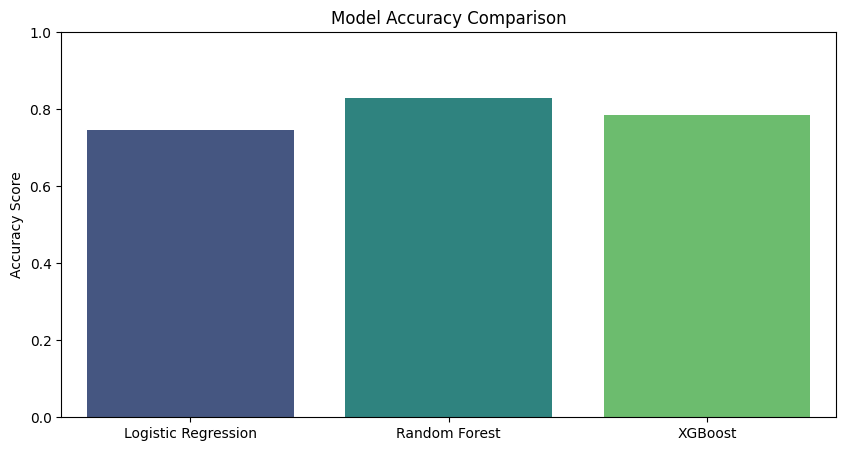

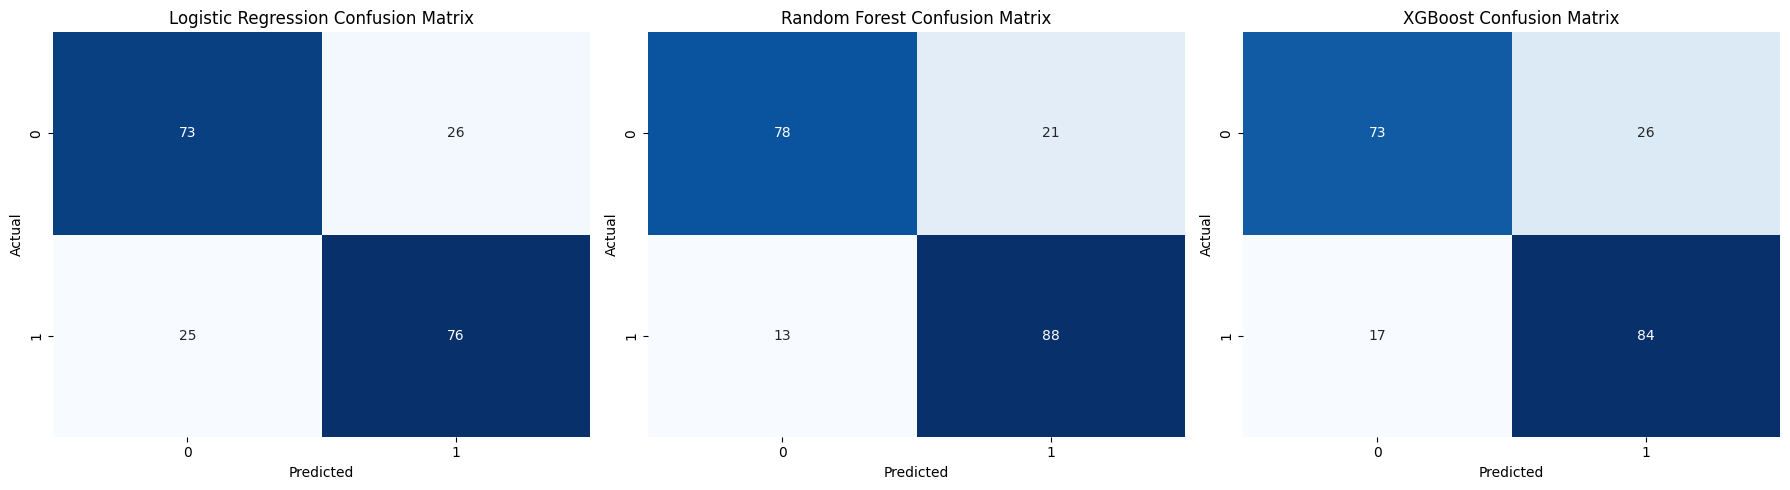

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Accuracy Comparison Chart
plt.figure(figsize=(10, 5))
accuracy_scores = [accuracy_score(y_test, model.predict(X_test)) for model in models.values()]
sns.barplot(x=list(models.keys()), y=accuracy_scores, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.show()

# 2. Confusion Matrices (Visualizing errors)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, model) in enumerate(models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()